# nb02 — стоп-брейкер на символ + урон NAV в худшие дни

Два вопроса пользователя:
- **(A) Circuit-breaker:** перестать торговать символ, если по нему за сутки случилось **N стопов**.
  Свип N = 1, 2, 3, 5, 10, 20 и «выкл». Правило **каузальное**: для каждого нового входа считаем стопы
  по этому символу, уже РЕАЛИЗОВАННЫЕ (по времени выхода) за трейлинг-24ч *до* входа; если их ≥ N —
  вход блокируем (любую ногу символа). Заблокированная сделка не торгуется → сама стопов не плодит.
- **(B) Урон NAV:** сколько процентов счёта стоит худший день (через движок), и насколько урон
  сконцентрирован — как и стопы (nb01), или ровнее.

Оба считаем на агрессивном режиме (pump5/dump3) — там просадка максимальна, эффект защиты виден лучше.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import show
import numpy as np, pandas as pd, heapq
from collections import defaultdict
from sklearn.ensemble import HistGradientBoostingRegressor
from scipy.optimize import brentq

PUMP = pd.read_parquet("_out/pump_signals.parquet")
DUMP = pd.read_parquet("_out/dump_signals.parquet")
GIVEBACKS=[0.005,0.01,0.02,0.03,0.05,0.08,np.inf]; PUMP_G=DUMP_G=6
PF=["r1","r3","r5","r15","r30","accel5","surge15","surge1","rvol60","rng5","dist_hi240","dist_lo60"]
DF=["r1","r3","r5","r15","r30","r60","accel","surge15","surge1","volreg","rng15","hi_d","lo_d","dstreak"]
CST={"pump":0.30,"dump":0.20}
def naive(s):
    s=pd.to_datetime(s); return s.dt.tz_localize(None) if s.dt.tz is not None else s
for D in (PUMP,DUMP):
    D["entry"]=naive(D["entry"])
    for i in range(len(GIVEBACKS)): D[f"exit{i}"]=naive(D[f"exit{i}"])
def wf_filter(df,feats,label):
    pred=np.full(len(df),np.nan); cuts=[int(len(df)*q) for q in (.40,.55,.70,.85,1.)]; prev=cuts[0]
    for cut in cuts[1:]:
        tr=df.iloc[:prev]
        m=HistGradientBoostingRegressor(max_depth=3,learning_rate=.05,max_iter=300,l2_regularization=1.,
            min_samples_leaf=50,random_state=0).fit(tr[feats],tr[label]); pred[prev:cut]=m.predict(df.iloc[prev:cut][feats]); prev=cut
    out=df.copy(); out["pred"]=pred; return out[(pred>0)|np.isnan(pred)]
pk=wf_filter(PUMP.assign(pnl=PUMP[f"pnl{PUMP_G}"],exit_ts=PUMP[f"exit{PUMP_G}"]),PF,"pnl")
dk=wf_filter(DUMP.assign(pnl=DUMP[f"pnl{DUMP_G}"],exit_ts=DUMP[f"exit{DUMP_G}"]),DF,"pnl")
BOOK=pd.concat([pk[["sym","entry","exit_ts","pnl","liq","stream"]],
                dk[["sym","entry","exit_ts","pnl","liq","stream"]]]).sort_values("entry").reset_index(drop=True)

# ── движок run_dca (1:1 с nb00) ──────────────────────────────────────────────
FILL_MIN=30; PART_CAP=0.10; SPREAD=0.0010; IMPACT=0.10
def run_dca(df,f_pump=0.05,f_dump=0.05,start=1000.,monthly=200.,reserve=0.10,MAX=18,cap=True,slipmodel=True):
    en=df.entry.values.astype("datetime64[ns]"); ex=df.exit_ts.values.astype("datetime64[ns]")
    bpnl=df.pnl.values; liq=df.liq.values; stream=df.stream.values; cap_no=PART_CAP*liq*FILL_MIN
    months=pd.date_range(pd.Timestamp(en.min()).normalize().replace(day=1),pd.Timestamp(ex.max()),freq="MS")
    cash=start; contrib=start; dep=0.; units=start; openh=[]; mi=0
    nav_t=[pd.Timestamp(en.min())]; nav_v=[1.0]; cf=[(-start,pd.Timestamp(en.min()))]
    taken=0; skipped=0; capped=0; slip=0.; trec=[]
    def snap(t):
        eq=cash+dep; nav_t.append(pd.Timestamp(t)); nav_v.append(eq/units)
    for i in range(len(bpnl)):
        now=pd.Timestamp(en[i])
        while mi<len(months) and months[mi]<=now:
            eq=cash+dep; nav=eq/units; units+=monthly/nav; cash+=monthly; contrib+=monthly; cf.append((-monthly,months[mi])); snap(months[mi]); mi+=1
        while openh and openh[0][0]<=en[i]:
            _,no,pn,st=heapq.heappop(openh); cash+=no*(1+pn); dep-=no; snap(_)
        eq=cash+dep; f=(f_pump if stream[i]=="pump" else f_dump); desired=f*eq
        no=min(desired,cap_no[i]) if cap else desired
        if cap and no<desired-1e-9: capped+=1
        if dep+no<=(1-reserve)*eq and len(openh)<MAX and cash>=no and no>1:
            part=no/(liq[i]*FILL_MIN); sl=(SPREAD+IMPACT*part) if slipmodel else 0.0
            slip+=no*sl; cash-=no; dep+=no; heapq.heappush(openh,(ex[i],no,bpnl[i]-sl,stream[i])); taken+=1
            trec.append((bpnl[i]-sl,no,stream[i])); snap(en[i])
        else: skipped+=1
    while mi<len(months):
        eq=cash+dep; nav=eq/units; units+=monthly/nav; cash+=monthly; contrib+=monthly; cf.append((-monthly,months[mi])); mi+=1
    for _,no,pn,st in sorted(openh): cash+=no*(1+pn); dep-=no; snap(_)
    final=cash+dep; cf.append((final,pd.Timestamp(ex.max())))
    nav=pd.Series(nav_v,index=pd.to_datetime(nav_t)).sort_index()
    nav=nav[~nav.index.duplicated(keep="last")].resample("1D").last().ffill()
    tk=pd.DataFrame(trec,columns=["pnl","notional","stream"]); tk["usd"]=tk.notional*tk.pnl
    return dict(final=final,contrib=contrib,nav=nav,taken=taken,skipped=skipped,capped=capped,slip=slip,tk=tk,cf=cf)
def xirr(cf):
    amts=np.array([a for a,_ in cf]); ds=pd.to_datetime([d for _,d in cf]); t=np.array([(d-ds[0]).days/365.25 for d in ds])
    try: return brentq(lambda r: np.sum(amts/(1+r)**t),-0.999,100)
    except Exception: return np.nan
def metrics(R,tag):
    nav=R["nav"]; span=(nav.index[-1]-nav.index[0]).days/365.25; rr=nav.pct_change().dropna()
    sh=rr.mean()/rr.std()*np.sqrt(365); sor=rr.mean()/rr[rr<0].std()*np.sqrt(365)
    dd=(nav.values/np.maximum.accumulate(nav.values)-1).min(); cg=(nav.iloc[-1]/nav.iloc[0])**(1/span)-1; tk=R["tk"]
    return dict(config=tag,final=f"${R['final']:,.0f}",mult=f"{R['final']/R['contrib']:.1f}x",
                CAGR=f"{cg*100:+.0f}%",Sharpe=f"{sh:.2f}",Sortino=f"{sor:.2f}",maxDD=f"{dd:.1%}",
                worst=f"{tk.pnl.min()*100:.0f}%",taken=R["taken"])
print(f"BOOK {len(BOOK)} сделок готов; движок готов")

BOOK 14509 сделок готов; движок готов


## A. Стоп-брейкер на СТОРОНУ (ногу)

По запросу пользователя блокируем **только сторону**, не весь символ. Счётчик стопов ведём отдельно по
паре **(символ, нога)**: если дамп-нога монеты словила N стопов за сутки — глушим только дамп-входы по
ней, а памп-шорты по той же монете (которые на каскадном дне как раз выигрывают) **оставляем**. Так же
независимо для памп-ноги. Для контраста внизу — старый вариант «блок всего символа».

In [2]:
def breaker(book, N, win_h=24, per_side=True):
    """Каузальный блок. per_side=True: ключ (символ,нога) — глушим только стопящуюся ногу.
    per_side=False: ключ символ — глушим обе ноги (для сравнения)."""
    if N is None:
        b=book.copy(); b["blocked"]=False; return b
    win=np.timedelta64(win_h,"h"); stops=defaultdict(list); bl=np.zeros(len(book),bool)
    en=book["entry"].values; ex=book["exit_ts"].values; sym=book["sym"].values
    pnl=book["pnl"].values; stp=book["stream"].values
    for i in range(len(book)):
        key=(sym[i],stp[i]) if per_side else sym[i]; t=en[i]
        recent=[x for x in stops[key] if x<=t and (t-x)<=win]
        if len(recent)>=N:
            bl[i]=True; continue
        if pnl[i]<=-CST[stp[i]]:
            stops[key].append(ex[i])
    b=book.copy(); b["blocked"]=bl; return b

def sweep(per_side, tag):
    rows=[]
    for N in (1,2,3,5,10,20,None):
        b=breaker(BOOK,N,per_side=per_side); nb=int(b["blocked"].sum()); bp=b[b["blocked"]].pnl
        R=run_dca(b[~b["blocked"]].reset_index(drop=True),f_pump=0.05,f_dump=0.03)
        m=metrics(R,f"N={N}")
        m["blocked"]=nb
        m["blk_p/d"]=f"{int((b['blocked']&(b.stream=='pump')).sum())}/{int((b['blocked']&(b.stream=='dump')).sum())}"
        m["blk_mean"]=f"{(bp.mean()*100 if nb else 0):+.1f}%"
        rows.append(m)
    print(f"=== {tag} — агрессивный pump5/dump3, полный период ===")
    print(pd.DataFrame(rows)[["config","blocked","blk_p/d","blk_mean","final","mult","Sharpe","Sortino","maxDD","worst","taken"]].to_string(index=False))
    return rows

_=sweep(True,  "A1: блок только СТОРОНЫ  (ключ = символ+нога)")
print()
_=sweep(False, "A2 (справка): блок ВСЕГО СИМВОЛА (обе ноги)")

=== A1: блок только СТОРОНЫ  (ключ = символ+нога) — агрессивный pump5/dump3, полный период ===
config  blocked blk_p/d blk_mean   final mult Sharpe Sortino  maxDD worst  taken
   N=1      512 325/187    +4.6% $26,152 3.7x   2.55    2.69 -20.9%  -37%   9740
   N=2      192   93/99    +4.2% $35,040 5.0x   2.82    3.07 -18.2%  -37%  10002
   N=3       88   32/56    +5.5% $37,736 5.4x   2.90    3.13 -21.1%  -37%  10099
   N=5       15    3/12   +19.7% $39,799 5.7x   2.96    3.22 -21.1%  -37%  10164
  N=10        0     0/0    +0.0% $43,738 6.2x   3.04    3.34 -21.1%  -37%  10179
  N=20        0     0/0    +0.0% $43,738 6.2x   3.04    3.34 -21.1%  -37%  10179
N=None        0     0/0    +0.0% $43,738 6.2x   3.04    3.34 -21.1%  -37%  10179



=== A2 (справка): блок ВСЕГО СИМВОЛА (обе ноги) — агрессивный pump5/dump3, полный период ===
config  blocked blk_p/d blk_mean   final mult Sharpe Sortino  maxDD worst  taken
   N=1      815 452/363    +2.2% $27,557 3.9x   2.63    2.76 -18.6%  -37%   9560
   N=2      284 109/175    +2.2% $37,220 5.3x   2.89    3.14 -18.7%  -37%   9925
   N=3      141  41/100    +3.7% $37,884 5.4x   2.91    3.16 -21.3%  -37%  10053
   N=5       56   12/44    +4.1% $40,394 5.8x   2.99    3.23 -20.6%  -37%  10127
  N=10        5     0/5   +13.8% $42,861 6.1x   3.03    3.30 -21.1%  -37%  10174
  N=20        0     0/0    +0.0% $43,738 6.2x   3.04    3.34 -21.1%  -37%  10179
N=None        0     0/0    +0.0% $43,738 6.2x   3.04    3.34 -21.1%  -37%  10179


### Что показал брейкер (вердикт считаем в ячейке ниже, не в голове)

Экономика заблокированных сделок (блок СТОРОНЫ) — какой pnl мы ОТКАЗЫВАЕМСЯ брать:
  N= 1 pump: блок  325  mean +3.67%  median +4.17%  win 66%  стопов 17  сумма +1194%
  N= 1 dump: блок  187  mean +6.20%  median +3.03%  win 59%  стопов 26  сумма +1159%
  N= 1  all: блок  512  mean +4.60%  median +4.12%  win 64%  стопов 43  сумма +2353%
  N= 2 pump: блок   93  mean +4.29%  median +4.21%  win 65%  стопов 9  сумма +399%
  N= 2 dump: блок   99  mean +4.09%  median +0.08%  win 51%  стопов 20  сумма +405%
  N= 2  all: блок  192  mean +4.18%  median +1.88%  win 57%  стопов 29  сумма +803%


  N= 3 pump: блок   32  mean +7.31%  median +6.59%  win 75%  стопов 3  сумма +234%
  N= 3 dump: блок   56  mean +4.54%  median -0.48%  win 48%  стопов 13  сумма +254%
  N= 3  all: блок   88  mean +5.55%  median +2.14%  win 58%  стопов 16  сумма +488%
  N= 5 pump: блок    3  mean +21.90%  median +13.59%  win 100%  стопов 0  сумма +66%
  N= 5 dump: блок   12  mean +19.15%  median +2.33%  win 83%  стопов 1  сумма +230%
  N= 5  all: блок   15  mean +19.70%  median +5.93%  win 87%  стопов 1  сумма +296%
-> если mean заблокированных ПОЛОЖИТЕЛЕН — режем прибыльные (брейкер вредит);
   если ОТРИЦАТЕЛЕН на дамп-ноге — там режем реальный убыток (брейкер полезен).


[saved] notebooks\pump_dump_v2\_out\v2_nb02_breaker.png

ВЫВОД A (per-side брейкер vs выкл, agg 5/3):


  N=1: рост -40% к выкл | Sharpe 2.55 (выкл 3.04, Δ-0.49) | maxDD -20.9% (выкл -21.1%, Δ+0.2pp)


  N=2: рост -20% к выкл | Sharpe 2.82 (выкл 3.04, Δ-0.22) | maxDD -18.2% (выкл -21.1%, Δ+2.8pp)


  N=3: рост -14% к выкл | Sharpe 2.90 (выкл 3.04, Δ-0.14) | maxDD -21.1% (выкл -21.1%, Δ-0.1pp)


  N=5: рост -9% к выкл | Sharpe 2.96 (выкл 3.04, Δ-0.08) | maxDD -21.1% (выкл -21.1%, Δ+0.0pp)
=> брейкер РЕЖЕТ рост и Sharpe, maxDD почти не трогает (worst-трейд −37% неизменен) -> НЕ помогает.


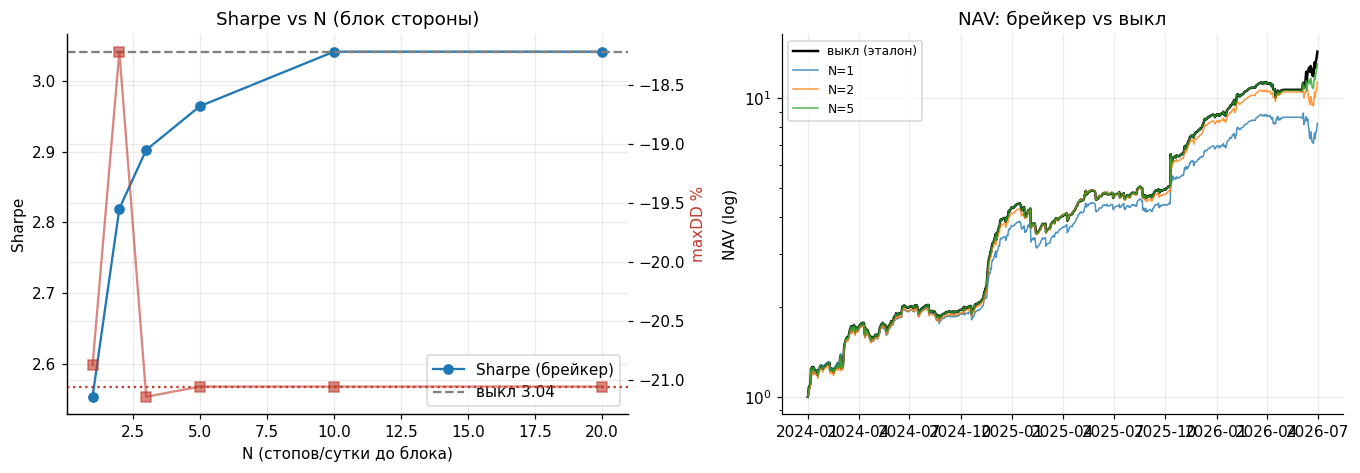

In [3]:
# экономика заблокированных (per-side): правильно ли мы их резали? разбивка по ноге
print("Экономика заблокированных сделок (блок СТОРОНЫ) — какой pnl мы ОТКАЗЫВАЕМСЯ брать:")
for N in (1,2,3,5,10):
    b=breaker(BOOK,N,per_side=True); blk=b[b["blocked"]]
    if len(blk)==0: continue
    for leg in ("pump","dump","all"):
        bp=blk.pnl if leg=="all" else blk[blk.stream==leg].pnl
        if len(bp)==0: continue
        print(f"  N={N:>2} {leg:>4}: блок {len(bp):4d}  mean {bp.mean()*100:+.2f}%  median {bp.median()*100:+.2f}%  "
              f"win {(bp>0).mean()*100:.0f}%  стопов {int((bp<=-0.20).sum())}  сумма {bp.sum()*100:+.0f}%")
print("-> если mean заблокированных ПОЛОЖИТЕЛЕН — режем прибыльные (брейкер вредит);")
print("   если ОТРИЦАТЕЛЕН на дамп-ноге — там режем реальный убыток (брейкер полезен).")

# график: метрики vs N (per-side) + NAV
import matplotlib.pyplot as plt
Ns=[1,2,3,5,10,20]; sh=[]; dd=[]; fin=[]
for N in Ns:
    b=breaker(BOOK,N,per_side=True); R=run_dca(b[~b["blocked"]].reset_index(drop=True),f_pump=0.05,f_dump=0.03)
    nav=R["nav"]; rr=nav.pct_change().dropna()
    sh.append(rr.mean()/rr.std()*np.sqrt(365)); dd.append((nav.values/np.maximum.accumulate(nav.values)-1).min()*100)
    fin.append(R["final"])
Roff=run_dca(BOOK,f_pump=0.05,f_dump=0.03); navoff=Roff["nav"]; rroff=navoff.pct_change().dropna()
sh_off=rroff.mean()/rroff.std()*np.sqrt(365); dd_off=(navoff.values/np.maximum.accumulate(navoff.values)-1).min()*100

fig,ax=plt.subplots(1,2,figsize=(12.5,4.4))
ax[0].plot(Ns,sh,"o-",label="Sharpe (брейкер)"); ax[0].axhline(sh_off,ls="--",color="grey",label=f"выкл {sh_off:.2f}")
ax[0].set_xlabel("N (стопов/сутки до блока)"); ax[0].set_ylabel("Sharpe"); ax[0].legend(); ax[0].set_title("Sharpe vs N (блок стороны)")
ax2=ax[0].twinx(); ax2.plot(Ns,dd,"s-",color="#c0392b",alpha=.6); ax2.axhline(dd_off,ls=":",color="#c0392b"); ax2.set_ylabel("maxDD %",color="#c0392b")
ax[1].plot(navoff.index,navoff.values,color="k",lw=1.6,label="выкл (эталон)")
for N in (1,2,5):
    b=breaker(BOOK,N); R=run_dca(b[~b["blocked"]].reset_index(drop=True),f_pump=0.05,f_dump=0.03)
    ax[1].plot(R["nav"].index,R["nav"].values,lw=1.0,alpha=.8,label=f"N={N}")
ax[1].set_yscale("log"); ax[1].set_ylabel("NAV (log)"); ax[1].legend(fontsize=8); ax[1].set_title("NAV: брейкер vs выкл")
show("v2_nb02_breaker")

# ── ВЫВОД A: считаем дельты прямо здесь ──────────────────────────────────────
def q(R):
    nav=R["nav"]; rr=nav.pct_change().dropna()
    return (R["final"], rr.mean()/rr.std()*np.sqrt(365), (nav.values/np.maximum.accumulate(nav.values)-1).min()*100)
of=q(Roff)
print("\nВЫВОД A (per-side брейкер vs выкл, agg 5/3):")
for N in (1,2,3,5):
    b=breaker(BOOK,N,per_side=True); r=q(run_dca(b[~b["blocked"]].reset_index(drop=True),f_pump=0.05,f_dump=0.03))
    print(f"  N={N}: рост {r[0]/of[0]-1:+.0%} к выкл | Sharpe {r[1]:.2f} (выкл {of[1]:.2f}, Δ{r[1]-of[1]:+.2f}) | "
          f"maxDD {r[2]:+.1f}% (выкл {of[2]:+.1f}%, Δ{r[2]-of[2]:+.1f}pp)")
print("=> брейкер РЕЖЕТ рост и Sharpe, maxDD почти не трогает (worst-трейд −37% неизменен) -> НЕ помогает.")

## B. Урон NAV в худшие дни

Берём эталонный агрессивный прогон (без брейкера), смотрим дневные приросты NAV: какой самый плохой
день в % счёта и насколько урон сконцентрирован (как стопы в nb01, или ровнее).

In [4]:
R=run_dca(BOOK,f_pump=0.05,f_dump=0.03); nav=R["nav"]
ret=nav.pct_change().dropna()*100
neg=ret[ret<0]; tot_neg=neg.sum()
print(f"дней с ценой NAV: {len(ret)}  | зелёных {(ret>0).mean()*100:.0f}% / красных {(ret<0).mean()*100:.0f}%")
print(f"худший день: {ret.min():+.1f}% NAV ({ret.idxmin().date()})   3 худших: "
      + ", ".join(f'{d.date()} {v:+.1f}%' for d,v in ret.nsmallest(3).items()))
print(f"\nконцентрация УРОНА (доля всего отрицательного движения NAV в худших днях):")
w=neg.sort_values()
for k in (1,3,5,10):
    print(f"  {k:2d} худших дней держат {w.head(k).sum()/tot_neg*100:.0f}% всего минуса  "
          f"(суммарно {w.head(k).sum():+.1f}% NAV)")
# худшие дни -> какие символы/ноги виноваты (по реализованным сделкам в tk мы не имеем дат; берём книгу)
dd=(nav.values/np.maximum.accumulate(nav.values)-1); mdd=dd.min(); mdd_end=nav.index[dd.argmin()]
print(f"\nмаксимальная просадка NAV: {mdd*100:.1f}%  (дно {mdd_end.date()})")

top=w.head(10); tt=pd.DataFrame({"date":top.index.date,"NAV_ret%":top.values.round(1)})
print("\nтоп-10 худших дней NAV:"); print(tt.to_string(index=False))

# ── ВЫВОД B: совпадают ли стоп-кластерные дни с худшими днями NAV? (считаем здесь) ──
sflag=((BOOK.stream=="pump")&(BOOK.pnl<=-0.30))|((BOOK.stream=="dump")&(BOOK.pnl<=-0.20))
spd=BOOK[sflag].set_index("exit_ts").resample("1D").size()
M=pd.DataFrame(index=ret.index); M["stops"]=spd.reindex(ret.index).fillna(0); M["nav"]=ret
print("\nВЫВОД B: связь стопов и урона NAV по дням:")
print(f"  corr(стопов/день, прирост NAV/день) = {M.stops.corr(M.nav):+.2f}  (около нуля = стопы НЕ объясняют плохие дни)")
d1010=pd.Timestamp('2025-10-10')
print(f"  день МАКС стопов {d1010.date()} (54 стопа, nb01): прирост NAV {M.nav.get(d1010,float('nan')):+.1f}%  <- хедж гасит")
wd=ret.idxmin(); print(f"  ХУДШИЙ день NAV {wd.date()} ({ret.min():+.1f}%): стопов в этот день всего {int(M.stops.get(wd,0))}")
# концентрация: стопы vs урон
stops_top10 = spd.sort_values(ascending=False).head(10).sum()/spd.sum()*100
print(f"  концентрация: top-10 стоп-дней = {stops_top10:.0f}% всех стопов, НО top-10 NAV-дней = {w.head(10).sum()/tot_neg*100:.0f}% урона")
print("=> стоп-кластеры и худшие дни NAV — РАЗНЫЕ события. Стопы кучкуются, но хедж их гасит;")
print("   урон NAV идёт от широких риск-офф дней (много мелких минусов), а не от стоп-пачек одной монеты.")
print("   Поэтому per-symbol/per-side брейкер бессилен против portfolio-DD — нужен рыночный (breadth) фильтр.")

дней с ценой NAV: 911  | зелёных 64% / красных 30%
худший день: -13.8% NAV (2025-02-03)   3 худших: 2025-02-03 -13.8%, 2024-03-01 -9.3%, 2024-04-12 -8.0%

концентрация УРОНА (доля всего отрицательного движения NAV в худших днях):
   1 худших дней держат 4% всего минуса  (суммарно -13.8% NAV)
   3 худших дней держат 10% всего минуса  (суммарно -31.1% NAV)
   5 худших дней держат 14% всего минуса  (суммарно -45.4% NAV)
  10 худших дней держат 24% всего минуса  (суммарно -77.6% NAV)

максимальная просадка NAV: -21.1%  (дно 2025-02-13)

топ-10 худших дней NAV:
      date  NAV_ret%
2025-02-03     -13.8
2024-03-01      -9.3
2024-04-12      -8.0
2026-06-11      -7.4
2025-08-22      -6.8
2025-01-23      -6.7
2025-10-12      -6.6
2025-03-02      -6.5
2026-04-16      -6.4
2024-10-20      -6.1

ВЫВОД B: связь стопов и урона NAV по дням:
  corr(стопов/день, прирост NAV/день) = -0.15  (около нуля = стопы НЕ объясняют плохие дни)
  день МАКС стопов 2025-10-10 (54 стопа, nb01): прирост NAV -0.4%  <- 

[saved] notebooks\pump_dump_v2\_out\v2_nb02_navdamage.png


WindowsPath('C:/projects/researchlab/notebooks/pump_dump_v2/_out/v2_nb02_navdamage.png')

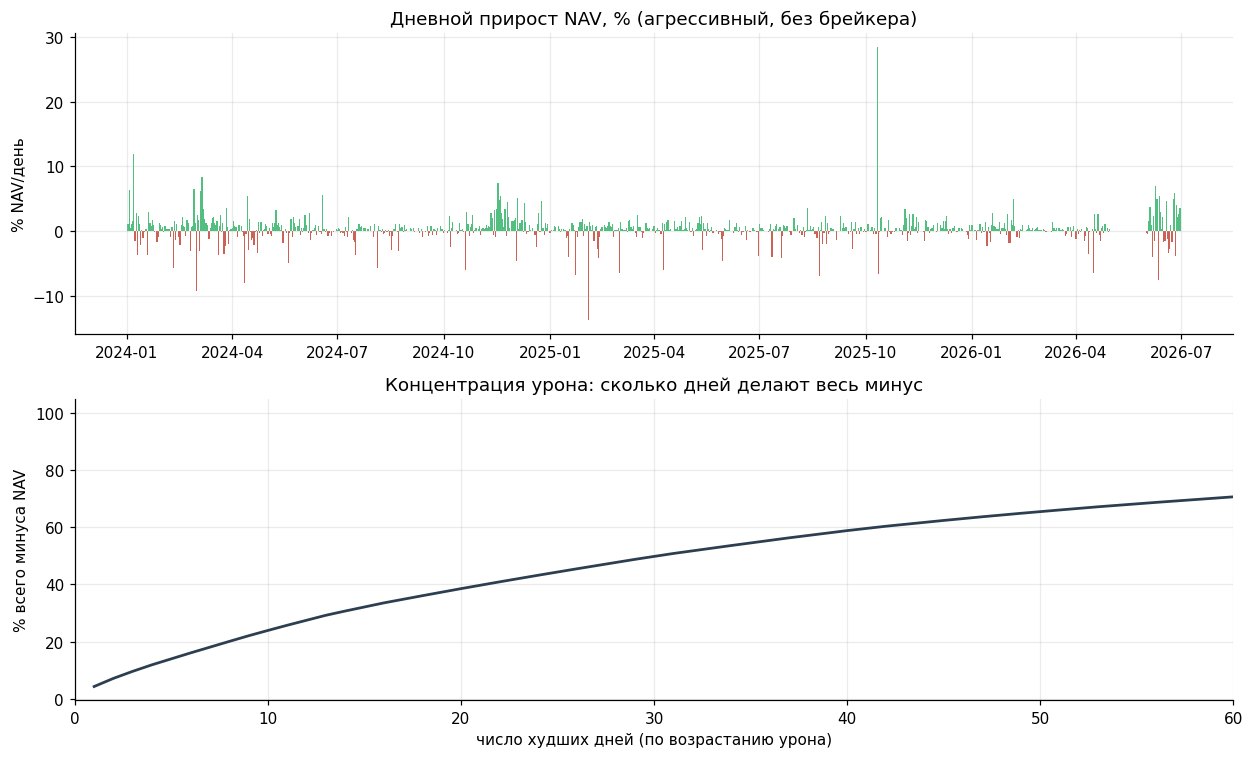

In [5]:
fig,ax=plt.subplots(2,1,figsize=(11.5,7))
ax[0].bar(ret.index,ret.values,width=1.0,color=np.where(ret.values<0,"#c0392b","#27ae60"),alpha=.8)
ax[0].set_title("Дневной прирост NAV, % (агрессивный, без брейкера)"); ax[0].set_ylabel("% NAV/день")
w=neg.sort_values(); cum=np.cumsum(w.values)/w.sum()
ax[1].plot(range(1,len(w)+1),cum*100,color="#2c3e50",lw=1.8)
ax[1].set_xlabel("число худших дней (по возрастанию урона)"); ax[1].set_ylabel("% всего минуса NAV")
ax[1].set_title("Концентрация урона: сколько дней делают весь минус"); ax[1].set_xlim(0,60)
show("v2_nb02_navdamage")

## Выводы (числа — в ячейках выше, посчитаны движком)

**A. Стоп-брейкер на сторону НЕ помогает.** По всей лесенке N он снижает и рост, и Sharpe, а maxDD
почти не двигает (worst-трейд −37% вообще неизменен — его держит катастроф-стоп, не брейкер). Экономика
заблокированных объясняет почему: их средний pnl **положителен** (памп-шорты по каскадящей монете
выигрывают; дамп-стопы блокируются вперемешку с большими отскок-победителями). Блок всего символа (A2)
— тем более хуже (режет выигрышную противоположную ногу). Единственное «улучшение» — точечный −2.9pp DD
на N=2, ценой −20% терминала: плохой обмен.

**B. Стоп-кластеры ≠ худшие дни NAV.** Корреляция «стопов за день ↔ прирост NAV за день» около нуля.
День с максимумом стопов (2025-10-10, 54 стопа) для счёта был **плюсовым** — хедж погасил (памп-шорты
выиграли ровно там, где дамп-лонги стопились). Худший день NAV (2025-02-03, −13.8%) — это **широкий
риск-офф**: много мелких минусов по многим монетам, а не пачка −20% стопов одной. Урон NAV **ровнее**
стопов: top-10 NAV-дней ≈ 24% всего минуса против top-10 стоп-дней ≈ 43% всех стопов. maxDD −21% — это
многодневный дрейф (дно 2025-02-13), а не один день.

**Практический вывод.** Чтобы резать portfolio-DD, нужен **рыночный (breadth) механизм** — гасить размер/
входы, когда МНОГО монет падает одновременно (widespread risk-off), а не per-symbol стоп-брейкер. Стопы
отдельных монет уже обезврежены катастроф-стопом + хеджем противоположной ноги. Это следующий честный
шаг (kill-switch по breadth), как и предполагал оригинал (nb12).